In [25]:
# 1. Adım: Bozuk dosyayı tarayıp "fixed.zip" adında yeni bir dosya yaratıyoruz
#!zip -FF imageWoof.zip --out fixed.zip

# 2. Adım: Eğer yeni dosya oluştuysa onu açmayı deniyoruz
#!unzip fixed.zip

Fix archive (-FF) - salvage what can
 Found end record (EOCDR) - says expect single disk archive
Scanning for entries...
 copying: imagewoof200/test/australian_terrier/ILSVRC2012_val_00003690.JPEG  (29072 bytes)
 copying: imagewoof200/test/australian_terrier/ILSVRC2012_val_00009052.JPEG  (20986 bytes)
 copying: imagewoof200/test/australian_terrier/ILSVRC2012_val_00011152.JPEG  (15688 bytes)
 copying: imagewoof200/test/australian_terrier/ILSVRC2012_val_00012460.JPEG  (17367 bytes)
 copying: imagewoof200/test/australian_terrier/ILSVRC2012_val_00017380.JPEG  (43739 bytes)
 copying: imagewoof200/test/australian_terrier/ILSVRC2012_val_00019830.JPEG  (29310 bytes)
 copying: imagewoof200/test/australian_terrier/ILSVRC2012_val_00022292.JPEG  (20809 bytes)
 copying: imagewoof200/test/australian_terrier/ILSVRC2012_val_00025912.JPEG  (43940 bytes)
 copying: imagewoof200/test/australian_terrier/ILSVRC2012_val_00027492.JPEG  (15817 bytes)
 copying: imagewoof200/test/australian_terrier/ILSVRC2012_va

In [26]:
#!rm fixed.zip

In [27]:
from pathlib import Path
data_path = Path("")
image_path = data_path / "imagewoof200"

In [28]:
import os
def check_data(dir_path):
  for dirpath, dirnames, filnenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filnenames)} images in '{dirpath}'.")

In [29]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [30]:
from torch.utils.data import dataloader
from torchvision import datasets, transforms

In [31]:
manual_transforms = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])


In [32]:
from torch.utils.data import DataLoader
NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    train_dir, test_dir, transform, batch_size, num_workers=NUM_WORKERS
):
  train_data = datasets.ImageFolder(train_dir, transform=transform)
  test_data = datasets.ImageFolder(test_dir, transform=transform)

  # get class names
  class_names = train_data.classes

  train_dataloader = DataLoader(
      train_data,
      batch_size = batch_size,
      shuffle = True,
      num_workers = num_workers,
      pin_memory = True
  )

  test_dataloader = DataLoader(
      test_data,
      batch_size = batch_size,
      shuffle = False,
      num_workers = num_workers,
      pin_memory=True
  )

  return train_dataloader, test_dataloader, class_names


In [33]:
train_dataloader, test_dataloader, class_names = create_dataloaders(
    train_dir, test_dir, manual_transforms, batch_size=32
)

In [34]:
train_dataloader

In [35]:
class_names

['australian_terrier',
 'beagle',
 'border_terrier',
 'dingo',
 'english_foxhound',
 'golden_retriever',
 'old_english_sheepdog',
 'rhodesian_ridgeback',
 'samoyed',
 'shih_tzu']

In [36]:
import torchvision

In [37]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

In [38]:
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [41]:
auto_transforms = weights.transforms() # manual transforma gerek olmuyor (efficient nette)

In [42]:
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [43]:
train_dataloader, test_dataloader, class_names = create_dataloaders(
    train_dir,
    test_dir,
    auto_transforms, # perform same data transforms on our own data as the pretrained model
    batch_size=32
)

In [44]:
import torch
torch.cuda.is_available()

True

In [45]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [46]:
device

'cuda'

In [54]:
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [48]:
! pip install torchinfo

In [49]:
from torchinfo import summary

In [52]:
summary(model=torchvision.models.efficientnet_b0(weights=weights).to(device),
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 1000]                --                        True
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        True
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        True
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        864                       True
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        64                        True
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential: 2-2  

In [55]:
for param in model.parameters():
  param.requires_grad = False

In [56]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace = True),
    torch.nn.Linear(in_features = 1280,
                    out_features=len(class_names),
                    bias = True)
).to(device)


In [58]:
summary(model,
        input_size=(32, 3, 224, 224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 10]             --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [59]:
from torch import nn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [71]:
def train_step(model, dataloader, loss_fn, optimizer, device):
  model.train()
  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    # 1. forward pass
    y_pred = model(X)

    # 2. loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. optimizer
    optimizer.zero_grad()

    # 4. backpropagation
    loss.backward()

    # 5. optimizer step (missing in previous version)
    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [72]:
def test_step(model, dataloader, loss_fn, device):
  model.eval()
  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device) # Moved this line to fix the error

      # 1. forward pass
      test_pred_logits = model(X)

      # 2. loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # 3. accuracy
      test_pred_labels = test_pred_logits.argmax(dim=1) # Corrected this line
      test_acc += (test_pred_labels == y).sum().item()/len(test_pred_labels)

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

In [73]:
def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, device, epochs = 5):
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []
  }

  for epoch in range(epochs):
    train_loss, train_acc = train_step(model,
                                       train_dataloader,
                                       loss_fn,
                                       optimizer,
                                       device)
    test_loss, test_acc = test_step(model,
                                    test_dataloader,
                                    loss_fn,
                                    device)

    print(f"Epoch: {epoch+1} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
    results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
  return results

In [74]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
start_time = timer()

results = train(model,
                train_dataloader,
                test_dataloader,
                optimizer,
                loss_fn,
                device,
                epochs=5)

end_time = timer()
total_train_time = end_time - start_time
print(f"Total training time: {total_train_time:.3f} seconds")

Epoch: 1 | Train loss: 1.3902 | Train acc: 0.6820 | Test loss: 0.7349 | Test acc: 0.8667
Epoch: 2 | Train loss: 0.6769 | Train acc: 0.8532 | Test loss: 0.5110 | Test acc: 0.8854
Epoch: 3 | Train loss: 0.5349 | Train acc: 0.8686 | Test loss: 0.4580 | Test acc: 0.8729
Epoch: 4 | Train loss: 0.4631 | Train acc: 0.8884 | Test loss: 0.4033 | Test acc: 0.8917
Epoch: 5 | Train loss: 0.4093 | Train acc: 0.8988 | Test loss: 0.4033 | Test acc: 0.8875
Total training time: 66.474 seconds


In [83]:
from matplotlib import pyplot as plt
from PIL import Image

def transform_predict(model,
                      image_path,
                      class_names,
                      image_size = (224, 224),
                      transform = None,
                      device = device):
  img = Image.open(image_path)

  if transform is not None:
    image_transform = transform
  else:
    image_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
  model.to(device)
  model.eval()

  with torch.inference_mode():
    transformed_image = image_transform(img).unsqueeze(dim=0)
    target_image_pred = model(transformed_image.to(device))

  target_image_pred_probs = torch.softmax(target_image_pred, dim = 1)
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim = 1)
  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
  plt.axis(False)


In [90]:
golden = data_path / "golden-retriever.jpeg"
kedi = data_path / "kedi.jpg"
shihtzu = data_path / "shihtzu.jpg"
dingo = data_path / "dingo.jpg"

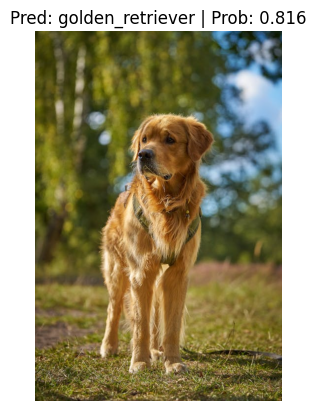

In [86]:
transform_predict(model, golden, class_names)

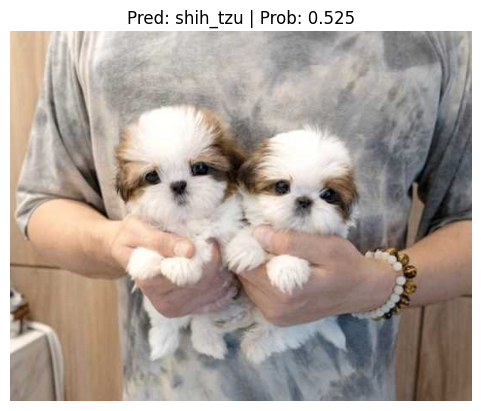

In [87]:
transform_predict(model, shihtzu, class_names)

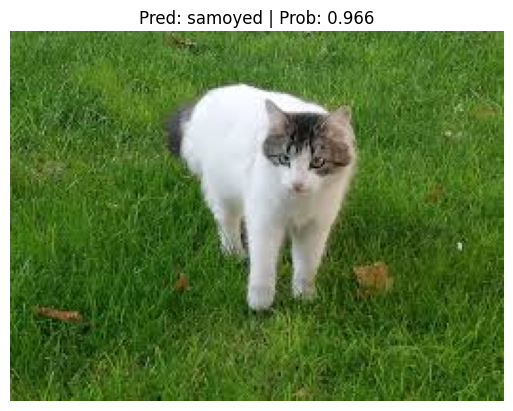

In [88]:
transform_predict(model, kedi, class_names)

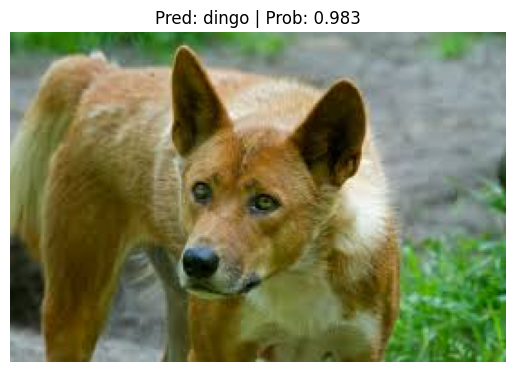

In [91]:
transform_predict(model, dingo, class_names)